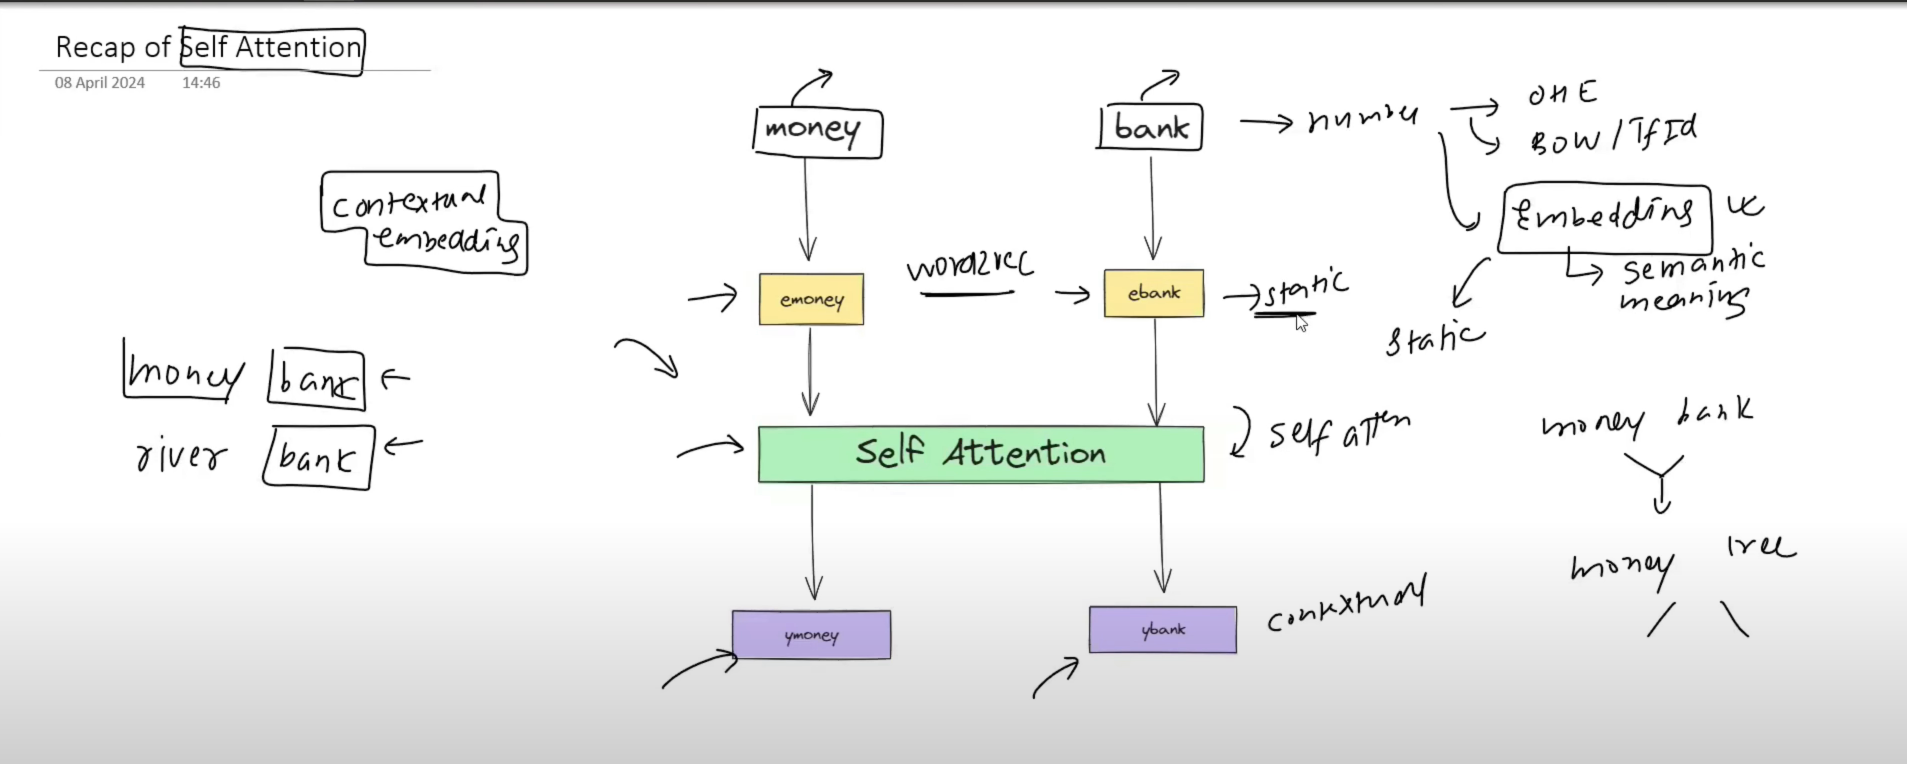

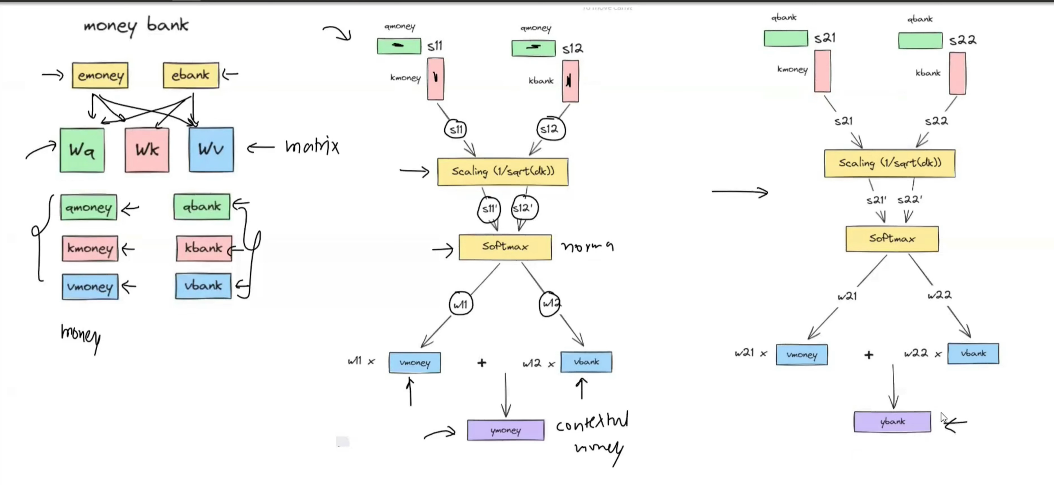

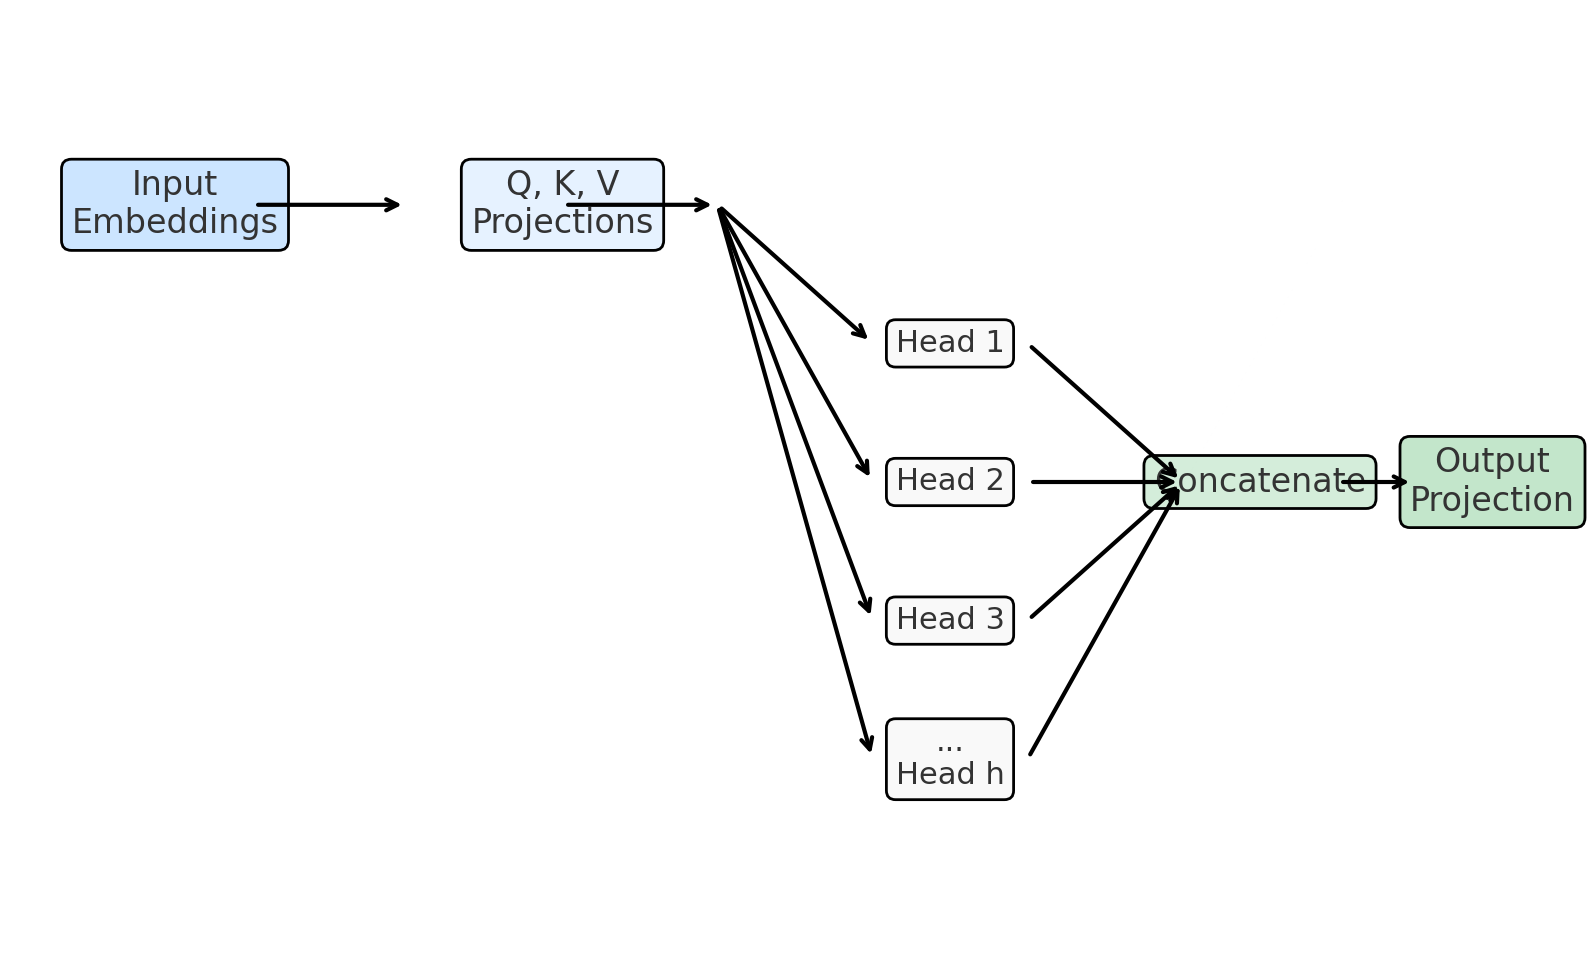
* Input embeddings are projected into multiple **Q, K, V sets**.
* Each **head** performs self-attention in parallel, capturing a different perspective.
* The outputs are **concatenated** and passed through a final **linear projection** to form the enriched embedding.




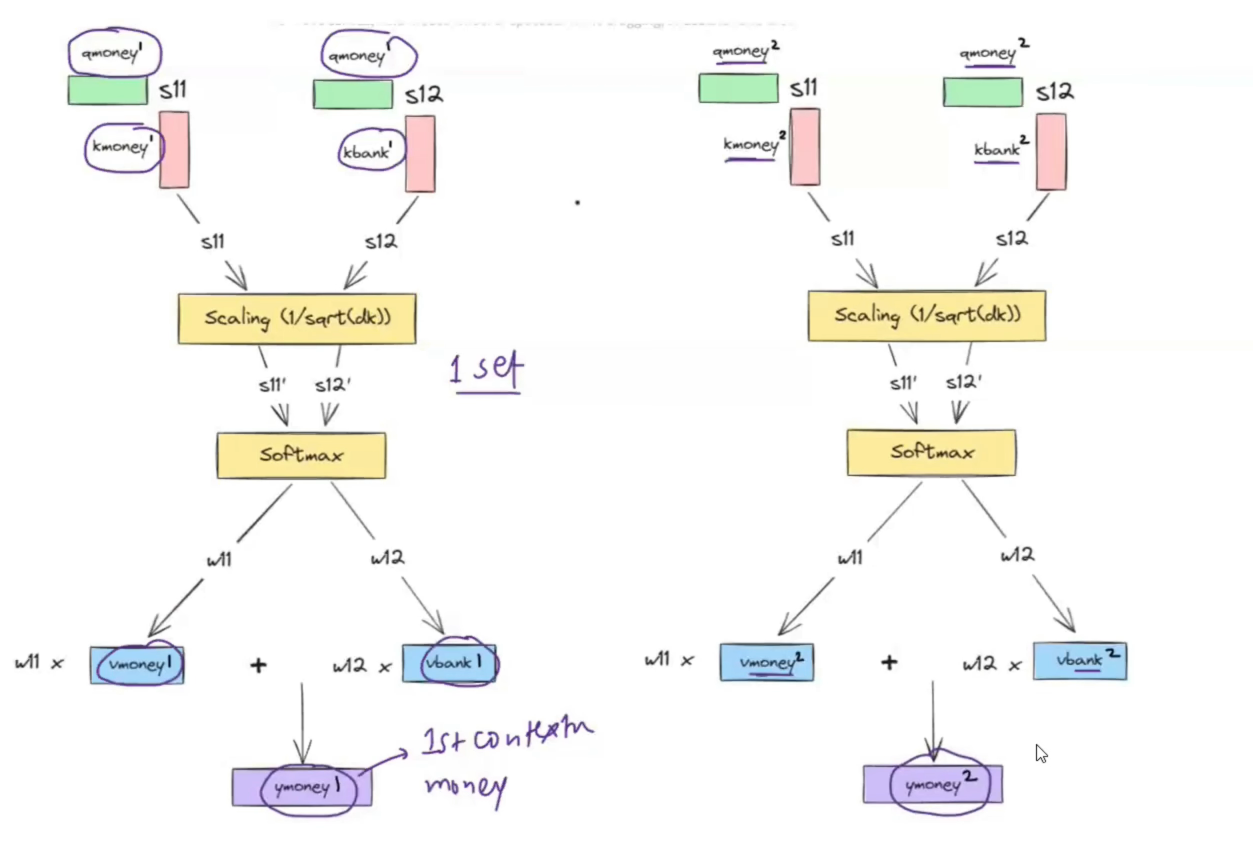

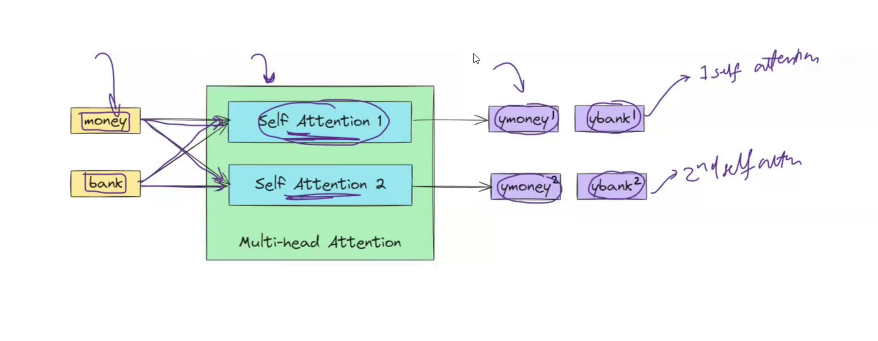

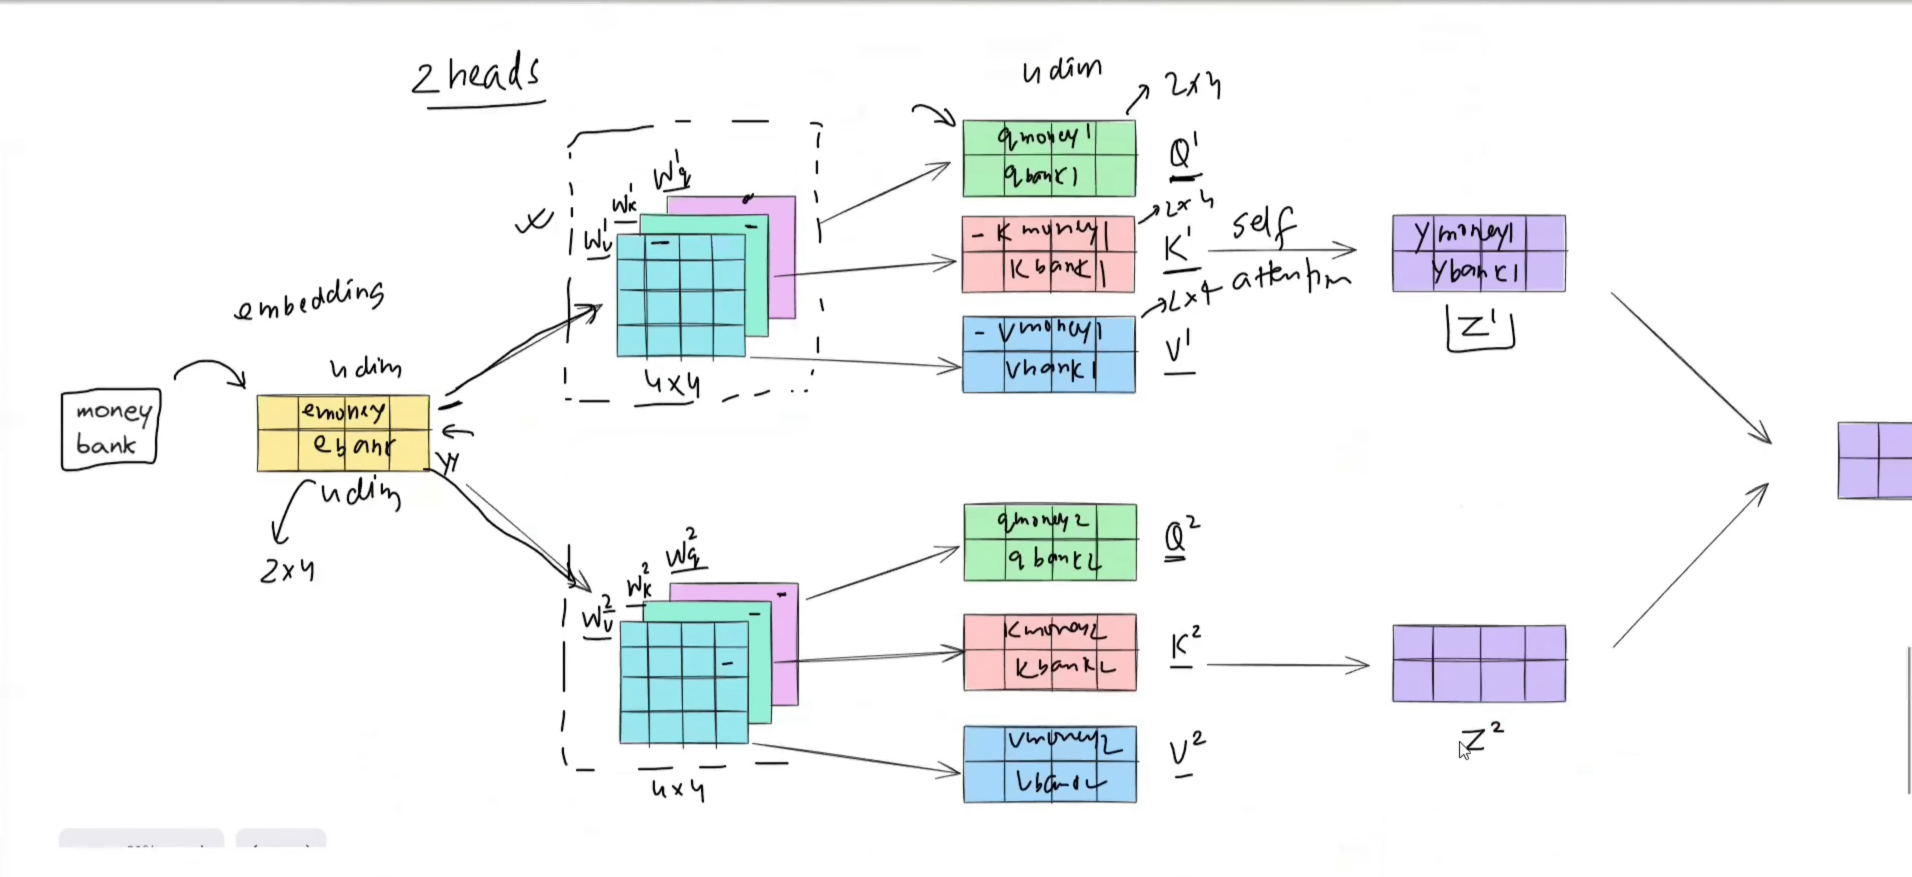

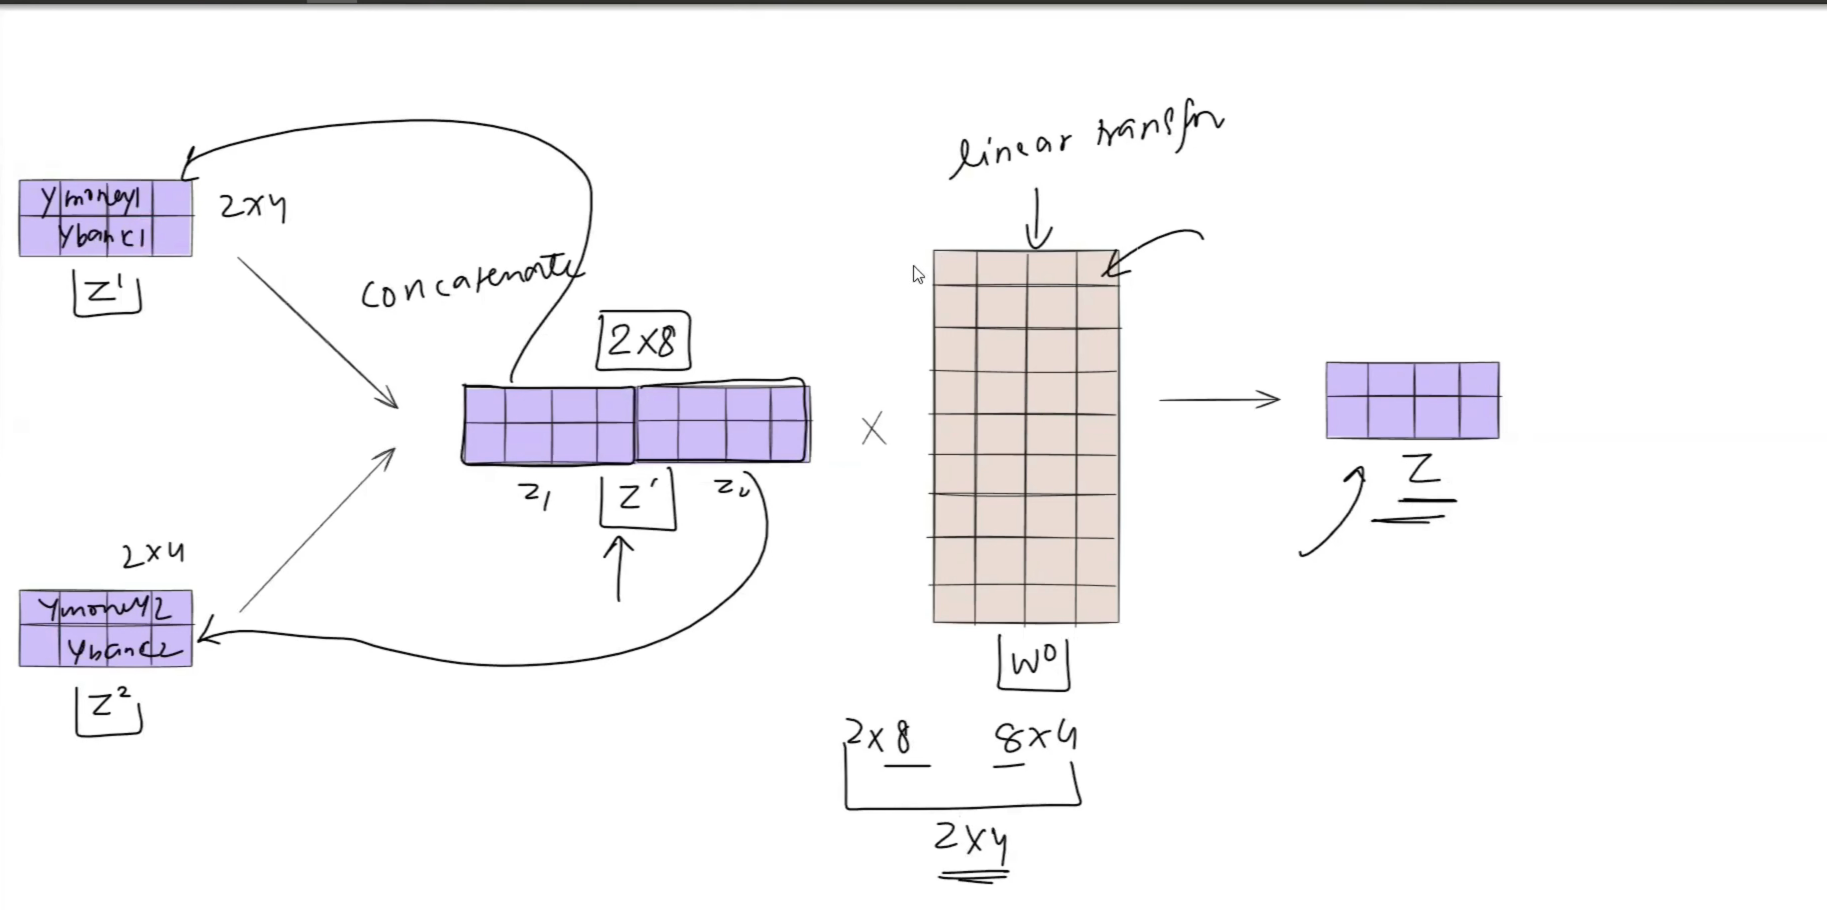

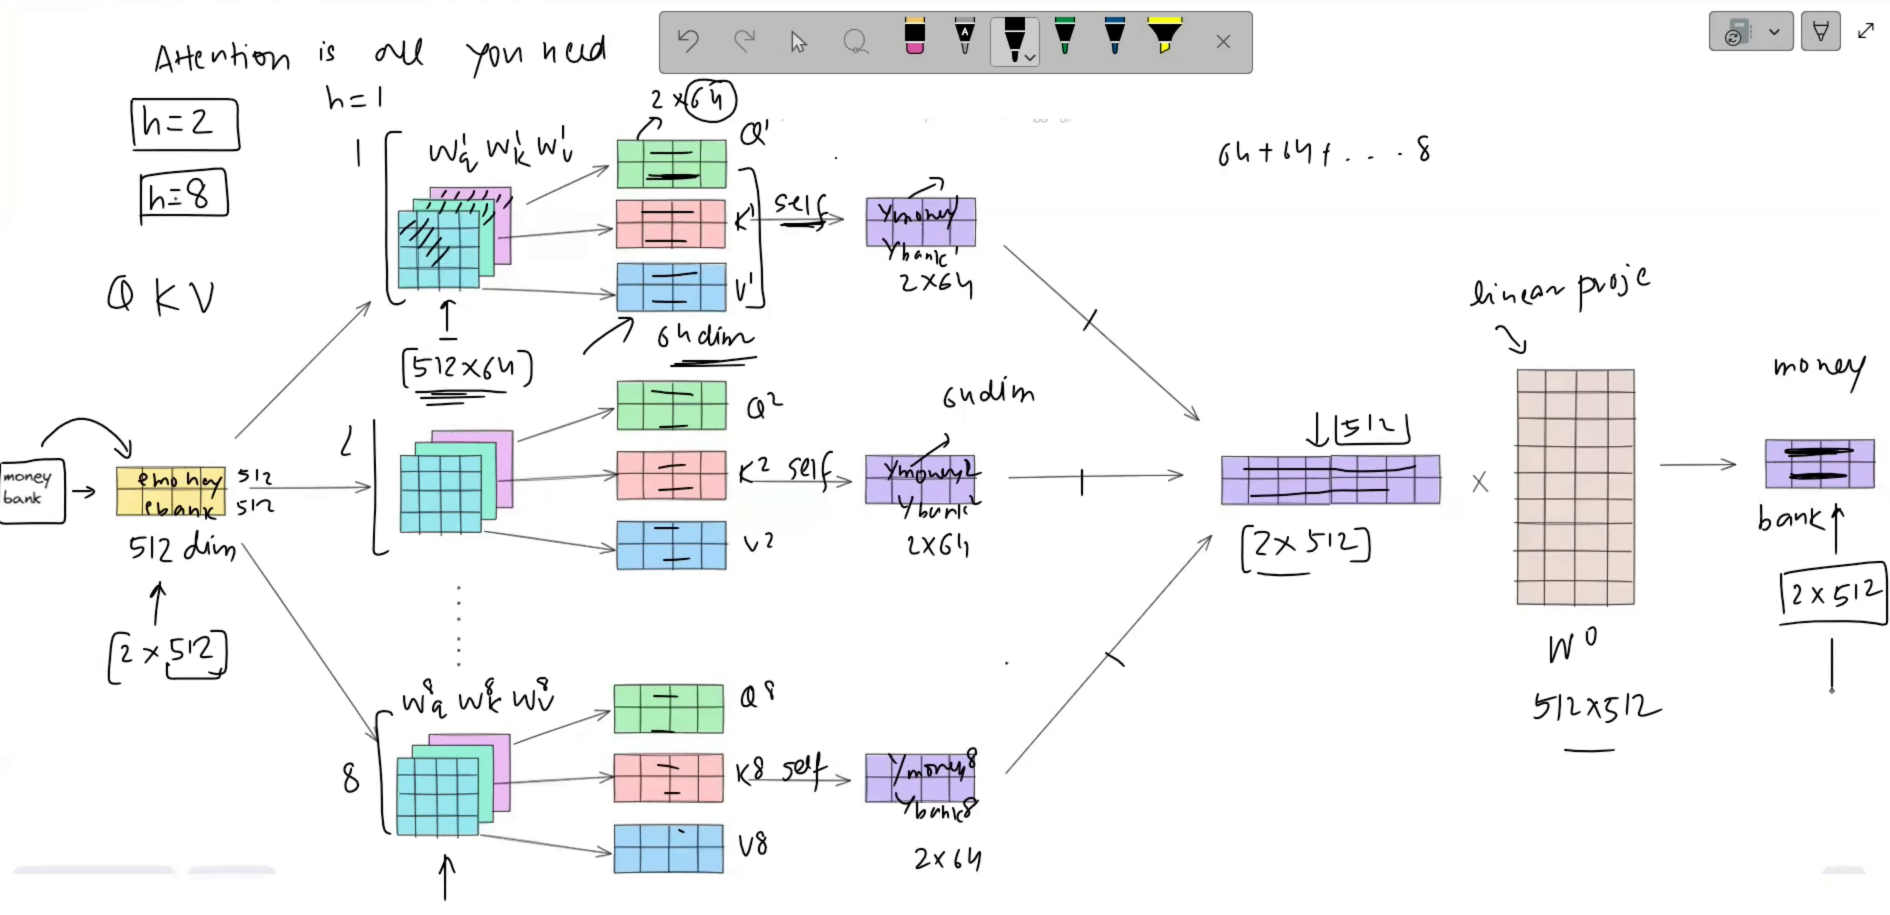



---

## 🔄 Step-by-Step Breakdown

### **1. Input Embeddings**

* Sentence: *“money bank”*
* Shape: **\[2 × 512]**

  * 2 words, each represented by a 512-dimensional embedding.

---

### **2. Q, K, V Projections (per head)**

* Each word embedding (512-dim) is multiplied by 3 learned matrices:

  * $W_Q, W_K, W_V \in \mathbb{R}^{512 \times 64}$
* For **head 1**:

  * $Q^1, K^1, V^1$ each become **\[2 × 64]**
* Same process for all 8 heads.

📌 *Why 64?*
Because total dimension (512) is divided across **8 heads** → 512 ÷ 8 = 64. This keeps computation efficient.

---

### **3. Self-Attention within each head**

For each head:

1. Compute similarity:
   $\text{Scores} = QK^\top / \sqrt{64}$ → **\[2 × 2]**
2. Apply softmax → attention weights.
3. Multiply by $V$:
   $Y = \text{Softmax}(QK^\top / \sqrt{64}) \cdot V$
   → produces contextual embeddings **\[2 × 64]** per head.

So, for 8 heads → we get 8 different **\[2 × 64]** matrices.

---

### **4. Concatenation of heads**

* Each head’s output: **\[2 × 64]**
* Concatenate along feature dimension:
  $[2 × (8 \cdot 64)] = [2 × 512]$
* Now each word has a **512-dim contextual vector**, but enriched by multiple perspectives.

---

### **5. Final Linear Projection**

* Concatenated matrix **\[2 × 512]** is passed through $W_O \in \mathbb{R}^{512 \times 512}$.
* Output stays **\[2 × 512]**, matching original embedding size.
* This ensures dimension consistency across layers in the Transformer.

---

## 🌟 Intuition per Step

1. **Input (static embeddings)** → just raw word vectors.
2. **Q, K, V per head** → different “views” of words.
3. **Attention in each head** → each head focuses on different relationships (syntax, meaning, position, etc.).
4. **Concatenation** → merging perspectives.
5. **Output projection** → blending multiple perspectives into one rich contextual embedding.

---


* Left = input and QKV projection.
* Middle = per-head self-attention results.
* Right = concatenation + final projection → contextual embeddings of “money” and “bank.”

---



Multi-Head Attention (MHA) is a critical component within the Transformer architecture, built upon the concept of Self-Attention. Its primary purpose is to address a significant limitation of Self-Attention, which is its inability to capture multiple perspectives or meanings from a given text.

### **Recap of Self-Attention**

To understand Multi-Head Attention, it's essential to first grasp Self-Attention:

*   **Problem Self-Attention Solves (Static Embeddings):** Traditional word representation methods like one-hot encoding, Bag-of-Words, TF-IDF, or Word2Vec produce **static embeddings**. This means a word, such as "bank," would have the exact same numerical representation (embedding value) regardless of its context in a sentence. For example, "money bank" and "river bank" would both use the identical static embedding for "bank," even though its meaning differs.
*   **Self-Attention's Solution (Contextual Embeddings):** Self-Attention addresses this by generating **contextual embeddings**. These are embeddings that change based on the word's surrounding context. So, "bank" in "money bank" would have a different embedding than "bank" in "river bank".
*   **How Self-Attention Works (High-Level):**
    1.  **Initial Embeddings:** It starts with static word embeddings (e.g., from a Word2Vec-like model) for each word in a sentence.
    2.  **Query, Key, Value (QKV) Vectors:** For each word's embedding, three new vectors are generated: Query (Q), Key (K), and Value (V) vectors. This is done by multiplying the word's embedding with three distinct weight matrices (W_Q, W_K, W_V).
    3.  **Similarity Scores:** The Query vector of one word is then dot-producted with the Key vectors of all other words (and itself) in the sentence to calculate **similarity scores**.
    4.  **Scaling and Softmax:** These scores are scaled and then normalized using a Softmax function to produce **attention weights**. These weights indicate how much attention each word should pay to every other word in the sentence.
    5.  **Contextual Embedding:** Finally, these attention weights are multiplied by the Value vectors of all words and summed up. This process generates a single **contextual embedding** for the original word, reflecting its meaning within that specific sentence. This entire process is repeated for every word in the sentence.

### **The Limitation of Self-Attention: Single Perspective**

Despite its power in generating contextual embeddings, Self-Attention has a notable limitation: it can only capture a **single perspective** or interpretation of an ambiguous sentence or document.

*   **Example of Ambiguity:** Consider the sentence: "The man saw the astronomer with a telescope".
    *   **Interpretation 1:** The man used a telescope to see the astronomer.
    *   **Interpretation 2:** The man saw an astronomer who possessed a telescope.
    *   Self-Attention would generate similarity scores that lean towards *only one* of these interpretations. For instance, it might show high similarity between "man" and "telescope" (implying the man used it), or between "astronomer" and "telescope" (implying the astronomer had it). It cannot capture both simultaneously.
*   **Impact on NLP Tasks:** In complex Natural Language Processing (NLP) tasks like document summarization, capturing multiple perspectives is crucial for generating a comprehensive summary. Relying solely on Self-Attention would result in a summary based on only one interpretation, potentially missing other important nuances.

### **Multi-Head Attention: The Solution for Multiple Perspectives**

Multi-Head Attention provides a simple yet powerful solution to Self-Attention's limitation by enabling the model to **capture multiple perspectives concurrently**.

*   **Core Idea:** Instead of using just one Self-Attention module (referred to as a "head"), MHA uses **multiple Self-Attention modules (heads) in parallel**. Each head learns to focus on different aspects of the input sequence.
*   **Architectural Breakdown (General Case):**
    1.  **Multiple Sets of QKV Weight Matrices:** Where Self-Attention uses one set of (W_Q, W_K, W_V) matrices, MHA uses **multiple distinct sets** (e.g., W_Q1, W_K1, W_V1 for Head 1; W_Q2, W_K2, W_V2 for Head 2, and so on for 'h' heads).
    2.  **Parallel QKV Vector Generation:** For each word's embedding, it is multiplied by *each* set of these weight matrices in parallel. This results in multiple sets of Q, K, V vectors for every word (e.g., Q_Money1, K_Money1, V_Money1 from Head 1, and Q_Money2, K_Money2, V_Money2 from Head 2).
    3.  **Parallel Self-Attention Computations:** Each "head" (Self-Attention module) then independently performs the entire Self-Attention process (calculating scores, scaling, Softmax, and weighted sum of Value vectors) using its specific set of Q, K, V vectors. This means that for a word like "Money," you would get Y_Money1 from Head 1 and Y_Money2 from Head 2, each representing a different contextual understanding.
    4.  **Concatenation of Outputs:** The contextual embeddings generated by all parallel heads are then **concatenated** (joined together). If each head outputs a vector of a certain dimension, concatenating 'h' such outputs will result in a combined vector 'h' times that dimension. For example, if two heads each output a 4-dimensional vector for "Money" and "Bank," the concatenated output would be 8-dimensional for each word (a 2x8 matrix for both words).
    5.  **Final Linear Transformation:** This concatenated output, which now combines multiple perspectives, is passed through a **final linear projection** using an "Output Weight Matrix" (W_Output). This transformation combines the diverse perspectives from the different heads and projects the output back to the original input embedding dimension. The weights within W_Output are learned during training, allowing the model to **balance and blend the importance** of each perspective to generate a final, enriched contextual embedding.

### **Multi-Head Attention in "Attention Is All You Need" Paper**

The original Transformer paper, "Attention Is All You Need," implemented MHA with some specific details:

*   **Input Dimension:** The initial word embeddings were 512-dimensional.
*   **Number of Heads:** The paper used **eight attention heads**.
*   **Dimension Reduction per Head:** A key optimization was that instead of each head processing 512-dimensional vectors, the input embeddings were **linearly projected to a lower dimension** for each head. Each W_Q, W_K, W_V matrix was designed to project the 512-dimensional input into 64-dimensional Q, K, V vectors for each head (512x64 matrices). So, the output of each head was a 64-dimensional contextual embedding.
*   **Computational Efficiency:** This dimension reduction was crucial for **reducing computational costs**. By dividing the 512 dimensions into 8 parts (64 dimensions per head), the total computational load for 8 parallel 64-dimensional Self-Attention heads was roughly equivalent to a single 512-dimensional Self-Attention, but with the added benefit of multiple perspectives.
*   **Concatenation:** The 8 outputs, each 64-dimensional, were concatenated. This brought the dimension back to 8 * 64 = 512 dimensions.
*   **Final Linear Projection:** This 512-dimensional concatenated output was then passed through a final W_Output matrix of shape 512x512. This produced a final output embedding that was also 512-dimensional, matching the original input.

### **Benefits and Visualization**

The primary benefits of Multi-Head Attention are:

*   **Diverse Perspectives:** It allows the model to simultaneously focus on different parts of the input, capturing various relationships and meanings within the text. Each head can learn to pay attention to different kinds of information.
*   **Rich Contextual Embeddings:** By combining these diverse perspectives, the final output embedding (after concatenation and linear transformation) becomes a more robust and **richer representation** of the word's context.
*   **Computational Balance:** The "Attention Is All You Need" implementation specifically demonstrated how to achieve these multiple perspectives without a significant increase in computational cost by dividing the embedding dimension among the heads.

A powerful visualization tool (like the one from Google AI) clearly demonstrates MHA in action. For the ambiguous sentence "The man saw the astronomer with a telescope":

*   **Head 1** might show a strong similarity between "man" and "telescope," suggesting the man used the telescope.
*   **Head 2** might show a strong similarity between "man" and "astronomer," and between "astronomer" and "telescope," suggesting the astronomer possessed the telescope.

This visual example illustrates how different heads effectively **capture distinct interpretations**, highlighting the power of Multi-Head Attention in understanding complex language. It essentially solves the single-perspective limitation of Self-Attention by running multiple Self-Attention processes in parallel, each learning a unique aspect or relationship in the data.



---

**1. What is Multi-Head Attention (MHA)?**
MHA is an extension of Self-Attention where **multiple Self-Attention heads run in parallel**, each capturing different relationships in the input.

---

**2. What problem does Self-Attention solve?**
It solves the issue of **static embeddings** (same vector for "bank" in both "river bank" and "money bank").
By computing Q, K, V vectors and attention weights, it produces **contextual embeddings** that change with context.

---

**3. What is Self-Attention’s limitation?**
It captures only **one perspective** at a time. For ambiguous sentences, it tends to commit to a single interpretation.

---

**4. How does MHA fix this?**
By using **multiple attention heads**, each can learn a different focus or perspective. Together, they capture richer, multi-view relationships.

---

**5. How was MHA designed in the Transformer paper?**

* **Input size:** 512
* **Heads:** 8
* **Per head:** projects 512 → 64 dimensions (Q, K, V)
* **Concat:** 8 × 64 = 512
* **Final projection:** 512 × 512 linear layer
* **Benefit:** Richer embeddings + efficient computation.

---




---

### **Single (Self-) Attention**

* **Process:**
  One set of Q, K, V matrices → one attention map.
* **Output:**
  Each token gets *one contextual embedding*.
* **Limitation:**
  Captures only a **single perspective** (e.g., in “the man saw the astronomer with a telescope,” it leans toward either *man–telescope* or *astronomer–telescope*, but not both).

---

### **Multi-Head Attention**

* **Process:**
  Multiple sets of Q, K, V matrices (one per head) → multiple attention maps in parallel.
* **Output:**
  Each head produces a contextual embedding → concatenated → projected back to original size.
* **Strength:**
  Captures **multiple perspectives simultaneously** (different heads can focus on different word relations or meanings).

---

### **Quick Analogy**

* **Single Attention = one camera lens** → you see the scene, but only one angle.
* **Multi-Head Attention = multiple lenses** → wide-angle, zoom, and macro views combined into a richer picture.

---


